# Hazard CONUS Grid - Hail M1 - Selected-Cell Pilot

**Peril:** hail - **Layer:** M1 hazard distribution - **Product:** `hazard_conus_grid`

This notebook starts the real selected-cell M1 pilot. It consumes the locked four-cell manifest and the
sparse MRMS daily evidence table, then writes:

1. a complete selected-cell x date panel with explicit zero-severe days; and
2. a tiny one-row-per-cell M1 hazard layer.

## Step back - where do the other data sources plug in?

This first M1 pilot is **MRMS-only by design**. It proves the grid contract before adding longer records,
de-biasing, or tail modeling.

```text
CURRENT PILOT

selected_pilot_cells_v2026_06_16.csv
  + MRMS daily MESH sparse positive evidence
  -> complete selected-cell x date panel
  -> pilot-window frequency + MESH size summaries
  -> tiny M1 hazard layer
```

The other sources plug in later at specific seams:

```text
MYRORSS
  -> new M0 gridded evidence notebook
     Notebooks/hail/m0_input_data/03_myrorss_reanalysis_source_qualification/
  -> normalized daily cell evidence, same schema as MRMS
  -> later M1 harmonization with MRMS

Storm Events / SPC
  -> validation / calibration overlay
  -> does not add grid events directly
  -> used to test report-side reasonableness and later bias calibration

Murillo & Homeyer
  -> broad climatology / MESH de-biasing anchor
  -> later validation target and possible correction recipe

Das & Allen / EVT tail
  -> tail-size modeling after the body distribution works
  -> needed before high-return-period PML / TVaR are treated as final

FEMA NRI
  -> downstream sanity check only
  -> not an M1 hazard source and not an asset-loss input
```

So: this notebook writes a **pilot M1 interface object**, not the final hail model.

Plan links:

- [`docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`](../../../../../docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md)
- [`docs/plans/hazard_conus_grid/hail/pilot.md`](../../../../../docs/plans/hazard_conus_grid/hail/pilot.md)
- [`docs/plans/hazard_conus_grid/output_schema.md`](../../../../../docs/plans/hazard_conus_grid/output_schema.md)

## 0 - Scope and non-goals

This notebook does:

- consume the selected-cell manifest;
- expand sparse MRMS positive evidence to a complete cell x date panel;
- compute pilot-window severe-hail-day counts;
- compute annualized pilot-window `lambda_cell` values;
- compute empirical MESH size summaries conditional on observed severe days;
- write a tiny M1 hazard layer with provenance and QA.

It deliberately does **not**:

- claim Apr-Jun 2024 is final climatology;
- estimate Negative Binomial dispersion from one partial season;
- use MYRORSS as a V1 input;
- de-bias MESH;
- fit EVT tails;
- calculate EAL, VaR, PML, or TVaR.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"

SELECTED_CELLS_CSV = HAIL_GRID_DIR / "selected_pilot_cells_v2026_06_16.csv"
DAILY_EVIDENCE_PATH = (
    HAIL_GRID_DIR / "m0_daily_cell_evidence" / "mrms_cell_day_evidence_202404_202406.parquet"
)

M1_VERSION = "v2026_06_16"
DAILY_PANEL_CSV = HAIL_GRID_DIR / f"m1_selected_cell_daily_panel_{M1_VERSION}.csv"
HAZARD_LAYER_CSV = HAIL_GRID_DIR / f"m1_selected_cell_hazard_layer_{M1_VERSION}.csv"
HAZARD_LAYER_JSON = HAIL_GRID_DIR / f"m1_selected_cell_hazard_layer_{M1_VERSION}.json"
WRITE_M1_ARTIFACTS = True

MRMS_SELECTION_START = "2024-04-01"
MRMS_SELECTION_END = "2024-06-30"
SOURCE_PRODUCT = "CONUS/MESH_Max_1440min_00.50"
THRESHOLD_MM = 25.4
N_NATIVE_PIXELS_PER_CELL_DAY = 625

print("repo root:", ROOT)
print("selected cells:", SELECTED_CELLS_CSV)
print("daily evidence:", DAILY_EVIDENCE_PATH)
print("M1 version:", M1_VERSION)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
selected cells: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv
daily evidence: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m0_daily_cell_evidence/mrms_cell_day_evidence_202404_202406.parquet
M1 version: v2026_06_16


## 1 - Load selected cells and sparse MRMS evidence

The selected-cell manifest is the M1 input list. Candidate and QA files are provenance only.

The MRMS evidence parquet is sparse: rows exist only for cell-days with at least one native MRMS pixel above
`25.4 mm`. M1 must materialize zero-severe days explicitly before any frequency calculation.

In [2]:
selected_cells = pd.read_csv(SELECTED_CELLS_CSV)
daily_positive = pd.read_parquet(DAILY_EVIDENCE_PATH)
daily_positive["date"] = pd.to_datetime(daily_positive["date"])

selected_ids = set(selected_cells["cell_id"].astype(int))
daily_selected_positive = daily_positive[daily_positive["cell_id"].isin(selected_ids)].copy()

display(
    selected_cells[
        [
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "selection_status",
            "allowed_use",
            "n_hail_days",
            "mesh_max_mm",
        ]
    ]
)
print("selected positive MRMS evidence rows:", len(daily_selected_positive))
display(daily_selected_positive.sort_values(["cell_id", "date"]).head(12))

,role,cell_id,lat_center,lon_center,selection_status,allowed_use,n_hail_days,mesh_max_mm
0,high_hail,329354,33.00,-101.50,selected_for_m1_pilot,selected-cell M1 pilot only,12,105.800003
1,medium_hail,261700,44.75,-95.00,selected_for_m1_pilot,selected-cell M1 pilot only,2,37.299999
2,low_hail,247197,47.25,-120.75,selected_for_m1_pilot,selected-cell M1 pilot only,0,NaN
3,hayhurst_reference,336544,31.75,-104.00,selected_for_m1_pilot,selected-cell M1 pilot only,2,33.299999


selected positive MRMS evidence rows: 16


,hazard,cell_id,date,source_product,source_timestamp,threshold_mm,n_native_pixels_observed,n_native_pixels_severe,severe_area_km2_approx,mesh_max_mm,mesh_mean_severe_mm,mesh_p50_mm,mesh_p90_mm,mesh_p95_mm,hail_day_flag,qa_flags
9469,hail,261700,2024-06-03,CONUS/MESH_Max_1440min_00.50,2024-06-03 23:30:00+00:00,25.4,625,3,3.0,26.799999,26.100000,25.900000,26.619999,26.709999,True,raw_mrms_mesh;negative_values_masked;native_pi...
11258,hail,261700,2024-06-13,CONUS/MESH_Max_1440min_00.50,2024-06-13 23:30:00+00:00,25.4,625,37,37.0,37.299999,28.659460,28.600000,31.240000,33.040001,True,raw_mrms_mesh;negative_values_masked;native_pi...
317,hail,329354,2024-04-08,CONUS/MESH_Max_1440min_00.50,2024-04-08 23:30:00+00:00,25.4,625,1,1.0,26.900000,26.900000,26.900000,26.900000,26.900000,True,raw_mrms_mesh;negative_values_masked;native_pi...
407,hail,329354,2024-04-09,CONUS/MESH_Max_1440min_00.50,2024-04-09 23:30:00+00:00,25.4,625,211,211.0,67.800003,31.758768,28.799999,41.700001,46.699997,True,raw_mrms_mesh;negative_values_masked;native_pi...
1481,hail,329354,2024-04-26,CONUS/MESH_Max_1440min_00.50,2024-04-26 23:30:00+00:00,25.4,625,1,1.0,25.600000,25.600000,25.600000,25.600000,25.600000,True,raw_mrms_mesh;negative_values_masked;native_pi...
2260,hail,329354,2024-05-02,CONUS/MESH_Max_1440min_00.50,2024-05-02 23:30:00+00:00,25.4,625,13,13.0,31.299999,27.500000,27.000000,30.359999,31.000000,True,raw_mrms_mesh;negative_values_masked;native_pi...
2418,hail,329354,2024-05-03,CONUS/MESH_Max_1440min_00.50,2024-05-03 23:30:00+00:00,25.4,625,1,1.0,25.500000,25.500000,25.500000,25.500000,25.500000,True,raw_mrms_mesh;negative_values_masked;native_pi...
2667,hail,329354,2024-05-04,CONUS/MESH_Max_1440min_00.50,2024-05-04 23:30:00+00:00,25.4,625,3,3.0,28.299999,26.633333,26.000000,27.840000,28.070000,True,raw_mrms_mesh;negative_values_masked;native_pi...
4783,hail,329354,2024-05-16,CONUS/MESH_Max_1440min_00.50,2024-05-16 23:30:00+00:00,25.4,625,1,1.0,25.799999,25.799999,25.799999,25.799999,25.799999,True,raw_mrms_mesh;negative_values_masked;native_pi...
8131,hail,329354,2024-05-29,CONUS/MESH_Max_1440min_00.50,2024-05-29 23:30:00+00:00,25.4,625,335,335.0,105.800003,45.134624,39.700001,67.540001,75.349998,True,raw_mrms_mesh;negative_values_masked;native_pi...


**Takeaway.** The selected cells are fixed. The sparse evidence only tells us where severe MRMS was observed;
it is not yet a frequency-ready panel.

## 2 - Field interpretation before modeling

This complete pass keeps the bases clear. The most important distinction is:

- `n_hail_days` in the selected manifest is the bounded-window candidate evidence.
- `lambda_cell` below is an annualized pilot-window rate for interface testing, not a final climatological
  annual rate.

In [3]:
field_dictionary = pd.DataFrame(
    [
        ("cell_id", "benchmark grid join key", "integer", "YES - M1 identity"),
        ("date", "calendar day in selected MRMS pilot window", "date", "YES - frequency denominator"),
        ("hail_day_flag", "whether this cell had >=1 severe native MRMS pixel that day", "boolean", "YES - count process"),
        ("n_native_pixels_observed", "native MRMS pixel centers assigned to the cell", "count, denominator", "YES - coverage base"),
        ("n_native_pixels_severe", "native MRMS pixels with MESH >= 25.4 mm", "count", "YES - severe-area proxy"),
        ("severe_area_km2_approx", "approximate severe native-pixel area", "km2 proxy", "YES - QA / later coupling context"),
        ("mesh_max_mm", "daily max raw MESH in the cell", "mm", "YES - conditional severity sample"),
        ("lambda_cell", "annualized severe-hail-day rate from pilot window", "events/year", "PILOT ONLY - not final climatology"),
        ("freq_dist", "declared count-family placeholder", "string", "PILOT ONLY - fit later with longer record"),
        ("fano_phi", "over-dispersion estimate", "unitless", "NOT ESTIMATED from one partial season"),
        ("sparse_cell_flag", "low observed hail-day count", "boolean", "YES - warns M2/M4 not to overtrust"),
    ],
    columns=["field", "what it is", "units / reference base", "how we use it"],
)
field_dictionary

,field,what it is,units / reference base,how we use it
0,cell_id,benchmark grid join key,integer,YES - M1 identity
1,date,calendar day in selected MRMS pilot window,date,YES - frequency denominator
2,hail_day_flag,whether this cell had >=1 severe native MRMS p...,boolean,YES - count process
3,n_native_pixels_observed,native MRMS pixel centers assigned to the cell,"count, denominator",YES - coverage base
4,n_native_pixels_severe,native MRMS pixels with MESH >= 25.4 mm,count,YES - severe-area proxy
5,severe_area_km2_approx,approximate severe native-pixel area,km2 proxy,YES - QA / later coupling context
6,mesh_max_mm,daily max raw MESH in the cell,mm,YES - conditional severity sample
7,lambda_cell,annualized severe-hail-day rate from pilot window,events/year,PILOT ONLY - not final climatology
8,freq_dist,declared count-family placeholder,string,PILOT ONLY - fit later with longer record
9,fano_phi,over-dispersion estimate,unitless,NOT ESTIMATED from one partial season


## 3 - Build the complete selected-cell x date panel

Missing sparse rows become explicit zero-severe days. This is the central M0->M1 move for the selected-cell
pilot.

In [4]:
dates = pd.date_range(MRMS_SELECTION_START, MRMS_SELECTION_END, freq="D")
date_frame = pd.DataFrame({"date": dates})

date_meta = (
    daily_positive.groupby("date")
    .agg(
        source_timestamp=("source_timestamp", "first"),
        source_product=("source_product", "first"),
        threshold_mm=("threshold_mm", "first"),
    )
    .reset_index()
)

panel = (
    selected_cells[
        [
            "hazard",
            "selection_version",
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "state_abbr",
            "iso_rto",
        ]
    ]
    .assign(_key=1)
    .merge(date_frame.assign(_key=1), on="_key")
    .drop(columns="_key")
)

panel = panel.merge(date_meta, on="date", how="left")
panel["source_product"] = panel["source_product"].fillna(SOURCE_PRODUCT)
panel["threshold_mm"] = panel["threshold_mm"].fillna(THRESHOLD_MM)
fallback_ts = pd.to_datetime(panel["date"].dt.strftime("%Y-%m-%d") + " 23:30:00", utc=True)
panel["source_timestamp"] = panel["source_timestamp"].fillna(fallback_ts)

evidence_columns = [
    "cell_id",
    "date",
    "n_native_pixels_observed",
    "n_native_pixels_severe",
    "severe_area_km2_approx",
    "mesh_max_mm",
    "mesh_mean_severe_mm",
    "mesh_p50_mm",
    "mesh_p90_mm",
    "mesh_p95_mm",
    "hail_day_flag",
    "qa_flags",
]

panel = panel.merge(daily_selected_positive[evidence_columns], on=["cell_id", "date"], how="left")

panel["n_native_pixels_observed"] = panel["n_native_pixels_observed"].fillna(N_NATIVE_PIXELS_PER_CELL_DAY).astype(int)
panel["n_native_pixels_severe"] = panel["n_native_pixels_severe"].fillna(0).astype(int)
panel["severe_area_km2_approx"] = panel["severe_area_km2_approx"].fillna(0.0)
panel["hail_day_flag"] = panel["hail_day_flag"].fillna(False).astype(bool)
panel["qa_flags"] = panel["qa_flags"].fillna(
    "zero_severe_day_materialized_from_selected_cell_panel;raw_mrms_mesh"
)
panel["m1_panel_status"] = np.where(panel["hail_day_flag"], "observed_severe_day", "explicit_zero_severe_day")

expected_rows = len(selected_cells) * len(dates)
print("panel rows:", len(panel), "| expected:", expected_rows)
print("date span:", panel["date"].min().date(), "to", panel["date"].max().date())
display(panel.groupby(["role", "cell_id", "m1_panel_status"]).size().reset_index(name="days"))

panel rows: 364 | expected: 364
date span: 2024-04-01 to 2024-06-30


,role,cell_id,m1_panel_status,days
0,hayhurst_reference,336544,explicit_zero_severe_day,89
1,hayhurst_reference,336544,observed_severe_day,2
2,high_hail,329354,explicit_zero_severe_day,79
3,high_hail,329354,observed_severe_day,12
4,low_hail,247197,explicit_zero_severe_day,91
5,medium_hail,261700,explicit_zero_severe_day,89
6,medium_hail,261700,observed_severe_day,2


**Takeaway.** The M1 pilot now has explicit zero days. Frequency can be computed from the full 91-day
denominator, not from missing sparse rows.

## 4 - Frequency and size summaries

The rate below is annualized only to satisfy the M1 interface contract in a pilot. Because the record is a
single partial hail-season window, the frequency family is a placeholder and `fano_phi` is deliberately
empty.

In [5]:
def q(series: pd.Series, quantile: float) -> float:
    clean = series.dropna()
    return float(clean.quantile(quantile)) if len(clean) else np.nan


record_days = int(len(dates))
record_years = record_days / 365.25

summary_rows: list[dict] = []
for _, cell in selected_cells.iterrows():
    cell_panel = panel[panel["cell_id"].eq(cell["cell_id"])].copy()
    severe = cell_panel[cell_panel["hail_day_flag"]].copy()
    mesh = severe["mesh_max_mm"]

    n_hail_days = int(cell_panel["hail_day_flag"].sum())
    lambda_cell = n_hail_days / record_years
    sparse = n_hail_days < 5

    summary_rows.append(
        {
            "hazard": "hail",
            "m1_version": M1_VERSION,
            "cell_id": int(cell["cell_id"]),
            "role": cell["role"],
            "lat_center": float(cell["lat_center"]),
            "lon_center": float(cell["lon_center"]),
            "state_abbr": cell["state_abbr"],
            "iso_rto": cell["iso_rto"],
            "coverage_flag": "covered_mrms_pilot_window",
            "record_span_start": MRMS_SELECTION_START,
            "record_span_end": MRMS_SELECTION_END,
            "record_days": record_days,
            "record_years": round(record_years, 6),
            "source_products": SOURCE_PRODUCT,
            "source_role": "MRMS spine; NOAA/NRI validation already completed; other sources deferred",
            "threshold_mm": THRESHOLD_MM,
            "n_native_pixels_observed_per_cell_day": N_NATIVE_PIXELS_PER_CELL_DAY,
            "n_hail_days": n_hail_days,
            "n_zero_severe_days": int((~cell_panel["hail_day_flag"]).sum()),
            "lambda_cell": round(lambda_cell, 6),
            "lambda_cell_basis": "annualized_from_apr_jun_2024_pilot_window_not_final_climatology",
            "freq_dist": "poisson_placeholder",
            "freq_fit_status": "not_fit_single_partial_season; interface_placeholder_only",
            "fano_phi": np.nan,
            "fano_phi_status": "not_estimated_single_partial_season",
            "sparse_cell_flag": bool(sparse),
            "zero_hail_flag": bool(n_hail_days == 0),
            "mesh_event_size_sample_n": int(len(mesh.dropna())),
            "mesh_size_distribution_basis": "daily cell max MESH conditional on hail_day_flag",
            "mesh_max_mm_observed": round(float(mesh.max()), 3) if len(mesh.dropna()) else np.nan,
            "mesh_mean_mm_observed": round(float(mesh.mean()), 3) if len(mesh.dropna()) else np.nan,
            "mesh_p50_mm_observed": round(q(mesh, 0.50), 3),
            "mesh_p90_mm_observed": round(q(mesh, 0.90), 3),
            "mesh_p95_mm_observed": round(q(mesh, 0.95), 3),
            "mesh_p99_mm_observed": round(q(mesh, 0.99), 3),
            "mean_daily_severe_native_pixels_when_hail": round(float(severe["n_native_pixels_severe"].mean()), 3)
            if len(severe)
            else np.nan,
            "total_native_pixels_severe": int(severe["n_native_pixels_severe"].sum()),
            "size_dist_status": "empirical_pilot_window" if n_hail_days else "no_observed_severe_days_in_pilot_window",
            "validation_flags": (
                "pilot_mrms_only;bounded_apr_jun_2024;not_final_climatology;"
                "noaa_nri_qa_available;zero_days_materialized"
            ),
            "provenance_selected_cells": str(SELECTED_CELLS_CSV.relative_to(ROOT)),
            "provenance_daily_evidence": str(DAILY_EVIDENCE_PATH.relative_to(ROOT)),
            "next_source_hooks": "add_myrorss_daily_evidence;murillo_homeyer_debias;spc_validation;evt_tail",
            "m1_usage": "selected-cell pilot only",
        }
    )

hazard_layer = pd.DataFrame(summary_rows)
hazard_layer

,hazard,m1_version,cell_id,role,lat_center,lon_center,state_abbr,iso_rto,coverage_flag,record_span_start,...,mesh_p95_mm_observed,mesh_p99_mm_observed,mean_daily_severe_native_pixels_when_hail,total_native_pixels_severe,size_dist_status,validation_flags,provenance_selected_cells,provenance_daily_evidence,next_source_hooks,m1_usage
0,hail,v2026_06_16,329354,high_hail,33.00,-101.50,TX,ERCOT,covered_mrms_pilot_window,2024-04-01,...,84.900,101.620,53.0,636,empirical_pilot_window,pilot_mrms_only;bounded_apr_jun_2024;not_final...,data/hazard_conus_grid/hail/selected_pilot_cel...,data/hazard_conus_grid/hail/m0_daily_cell_evid...,add_myrorss_daily_evidence;murillo_homeyer_deb...,selected-cell pilot only
1,hail,v2026_06_16,261700,medium_hail,44.75,-95.00,MN,MISO,covered_mrms_pilot_window,2024-04-01,...,36.775,37.195,20.0,40,empirical_pilot_window,pilot_mrms_only;bounded_apr_jun_2024;not_final...,data/hazard_conus_grid/hail/selected_pilot_cel...,data/hazard_conus_grid/hail/m0_daily_cell_evid...,add_myrorss_daily_evidence;murillo_homeyer_deb...,selected-cell pilot only
2,hail,v2026_06_16,247197,low_hail,47.25,-120.75,WA,WEIM,covered_mrms_pilot_window,2024-04-01,...,NaN,NaN,NaN,0,no_observed_severe_days_in_pilot_window,pilot_mrms_only;bounded_apr_jun_2024;not_final...,data/hazard_conus_grid/hail/selected_pilot_cel...,data/hazard_conus_grid/hail/m0_daily_cell_evid...,add_myrorss_daily_evidence;murillo_homeyer_deb...,selected-cell pilot only
3,hail,v2026_06_16,336544,hayhurst_reference,31.75,-104.00,TX,ERCOT,covered_mrms_pilot_window,2024-04-01,...,32.930,33.226,8.0,16,empirical_pilot_window,pilot_mrms_only;bounded_apr_jun_2024;not_final...,data/hazard_conus_grid/hail/selected_pilot_cel...,data/hazard_conus_grid/hail/m0_daily_cell_evid...,add_myrorss_daily_evidence;murillo_homeyer_deb...,selected-cell pilot only


**Takeaway.** The output has the intended M1 shape, but the rate and size summaries are pilot-window
estimates. The low cell correctly carries an explicit zero-hail state instead of disappearing from the
table.

## 5 - QA plots

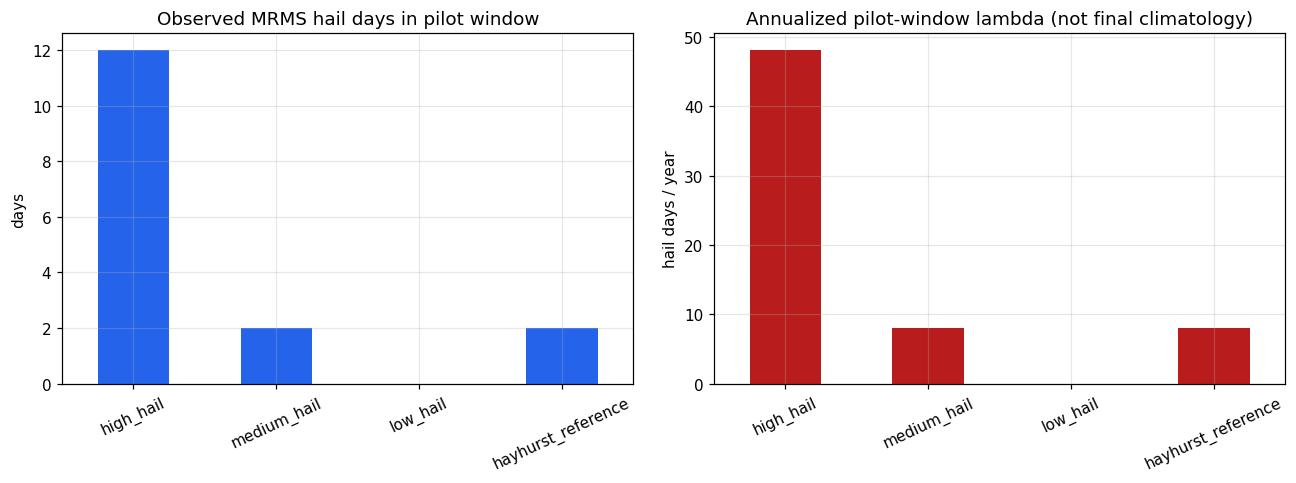

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
hazard_layer.plot.bar(x="role", y="n_hail_days", ax=ax[0], legend=False, color="#2563eb")
ax[0].set(title="Observed MRMS hail days in pilot window", xlabel="", ylabel="days")
ax[0].tick_params(axis="x", rotation=25)

hazard_layer.plot.bar(x="role", y="lambda_cell", ax=ax[1], legend=False, color="#b91c1c")
ax[1].set(title="Annualized pilot-window lambda (not final climatology)", xlabel="", ylabel="hail days / year")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

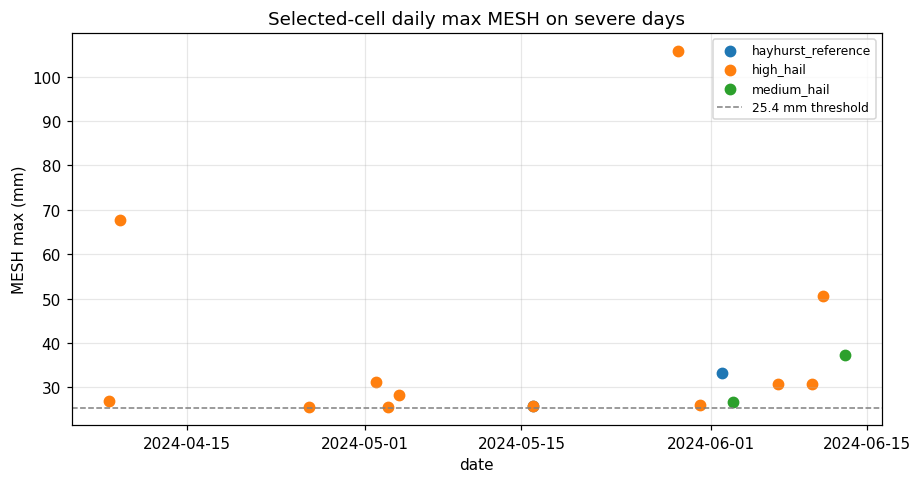

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for role, group in panel[panel["hail_day_flag"]].groupby("role"):
    ax.scatter(group["date"], group["mesh_max_mm"], label=role, s=45)
ax.axhline(THRESHOLD_MM, color="gray", ls="--", lw=1, label="25.4 mm threshold")
ax.set(title="Selected-cell daily max MESH on severe days", xlabel="date", ylabel="MESH max (mm)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Takeaway.** The pilot spans the intended cases: high has repeated severe days, medium/reference are sparse
but nonzero, and low has no severe MRMS cell-days in the pilot window.

## 6 - Write M1 pilot artifacts

The daily panel is small and explicit. The one-row-per-cell hazard layer is the M1 object that later M2
should read.

In [8]:
metadata = {
    "artifact": HAZARD_LAYER_CSV.name,
    "status": "m1_selected_cell_pilot_mrms_only",
    "m1_version": M1_VERSION,
    "hazard": "hail",
    "record_span": {"start": MRMS_SELECTION_START, "end": MRMS_SELECTION_END, "days": record_days},
    "allowed_use": "selected-cell M1 interface pilot and downstream M2-M4 smoke test",
    "not_allowed_use": "not final climatology; not full CONUS; not reportable EAL/PML/VaR/TVaR",
    "source_products": [SOURCE_PRODUCT],
    "source_flow": [
        {
            "source": "MRMS daily MESH",
            "status": "used_now",
            "role": "gridded spine for selected-cell pilot",
        },
        {
            "source": "MYRORSS",
            "status": "deferred",
            "where_added": "Notebooks/hail/m0_input_data/03_myrorss_reanalysis_source_qualification/",
            "role": "long-record gridded evidence extension after MRMS contract is proven",
        },
        {
            "source": "NOAA Storm Events / SPC",
            "status": "validation_now_calibration_later",
            "role": "report-side QA and later bias calibration, not grid truth",
        },
        {
            "source": "Murillo & Homeyer",
            "status": "deferred",
            "role": "MESH de-biasing recipe and broad climatology validation target",
        },
        {
            "source": "Das & Allen / EVT",
            "status": "deferred",
            "role": "tail-size modeling before high-return-period risk readouts",
        },
        {
            "source": "FEMA NRI",
            "status": "sanity_check_only",
            "role": "not M1 and not asset loss input",
        },
    ],
    "outputs": {
        "daily_panel": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "hazard_layer": str(HAZARD_LAYER_CSV.relative_to(ROOT)),
        "metadata": str(HAZARD_LAYER_JSON.relative_to(ROOT)),
    },
    "caveats": [
        "Apr-Jun 2024 is a pilot window, not final climatology.",
        "lambda_cell is annualized from a partial hail-season window and is for interface testing only.",
        "freq_dist is a Poisson placeholder because over-dispersion cannot be estimated from one partial season.",
        "Raw MRMS MESH is not de-biased.",
        "EVT/tail modeling is not included.",
    ],
}

if WRITE_M1_ARTIFACTS:
    panel.to_csv(DAILY_PANEL_CSV, index=False)
    hazard_layer.to_csv(HAZARD_LAYER_CSV, index=False)
    HAZARD_LAYER_JSON.write_text(json.dumps(metadata, indent=2))
    print("wrote daily panel:", DAILY_PANEL_CSV)
    print("wrote M1 hazard layer:", HAZARD_LAYER_CSV)
    print("wrote M1 metadata:", HAZARD_LAYER_JSON)
else:
    print("WRITE_M1_ARTIFACTS is False; no files written")

wrote daily panel: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m1_selected_cell_daily_panel_v2026_06_16.csv
wrote M1 hazard layer: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m1_selected_cell_hazard_layer_v2026_06_16.csv
wrote M1 metadata: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m1_selected_cell_hazard_layer_v2026_06_16.json


## 7 - Recap and next step

What this notebook established:

- the selected-cell M1 pilot can consume the locked manifest;
- sparse positive MRMS evidence can be expanded to a complete panel with explicit zero days;
- a tiny one-row-per-cell hazard layer can be written with frequency, severity, provenance, and QA fields;
- other data sources have clear future insertion points and are not silently mixed into this MRMS-only pilot.

Next:

1. This tiny hazard layer already fed the canonical solar M2-M4 smoke test.
2. The MRMS-only full-grid one-day V1 proof is now the active successor.
3. Build the MRMS source inventory and batch contract next; keep MYRORSS/de-bias/tail work for V1.5/V2.